In [1]:
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import yfinance as yfin
from datetime import date

pd.options.display.float_format="{:,.6f}".format

In [2]:
start = datetime.date(2019,3,25)
end = datetime.date(2026,3,25)

In [3]:
df_bc = yfin.download(['BTC-USD'], start=start, end=end, auto_adjust=False)['Adj Close']
df_bc.index = df_bc.index.tz_localize('UTC')
df_bc.head()

[*********************100%***********************]  1 of 1 completed


Ticker,BTC-USD
Date,
2019-03-25 00:00:00+00:00,"3,963.070557"
2019-03-26 00:00:00+00:00,"3,985.080811"
2019-03-27 00:00:00+00:00,"4,087.066162"
2019-03-28 00:00:00+00:00,"4,069.107178"
2019-03-29 00:00:00+00:00,"4,098.374512"


In [4]:
df_bc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2558 entries, 2019-03-25 00:00:00+00:00 to 2026-03-25 00:00:00+00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BTC-USD  2557 non-null   float64
dtypes: float64(1)
memory usage: 40.0 KB


In [5]:
url="https://raw.githubusercontent.com/Sahdam/Nigerian-Financial-Risk-Intelligence-System/refs/heads/main/Dangote%20Cement%20Stock%20Price%20History%20(1).csv"
df_dg = pd.read_csv(url, parse_dates=['Date'], index_col='Date')['Price']
df_dg.index = df_dg.index.tz_localize('UTC')
df_dg.rename('DANGCEM', inplace=True)
df_dg = df_dg.sort_index(ascending=True)
df_dg.head()

,DANGCEM
Date,
2019-03-25 00:00:00+00:00,188.500000
2019-03-26 00:00:00+00:00,190.000000
2019-03-27 00:00:00+00:00,190.000000
2019-03-28 00:00:00+00:00,190.000000
2019-03-29 00:00:00+00:00,191.000000


In [6]:
url1="https://raw.githubusercontent.com/Sahdam/Nigerian-Financial-Risk-Intelligence-System/refs/heads/main/Zenith%20Bank%20Stock%20Price%20History.csv"
df_z = pd.read_csv(url1, parse_dates=['Date'], index_col='Date')['Price']
df_z.index = df_z.index.tz_localize('UTC')
df_z.rename('ZENITHBANK', inplace=True)
df_z = df_z.sort_index(ascending=True)
df_z.head()

,ZENITHBANK
Date,
2019-03-25 00:00:00+00:00,21.500000
2019-03-26 00:00:00+00:00,21.700000
2019-03-27 00:00:00+00:00,22.000000
2019-03-28 00:00:00+00:00,21.800000
2019-03-29 00:00:00+00:00,21.800000


In [7]:
url2="https://raw.githubusercontent.com/Sahdam/Nigerian-Financial-Risk-Intelligence-System/refs/heads/main/MTN%20Nigeria%20Stock%20Price%20History.csv"
df_mtn = pd.read_csv(url2, parse_dates=['Date'], index_col='Date')['Price']
df_mtn.index = df_mtn.index.tz_localize('UTC')
df_mtn.rename('MTNN', inplace=True)
df_mtn = df_mtn.sort_index(ascending=True)
df_mtn.head()

,MTNN
Date,
2019-05-17 00:00:00+00:00,108.900000
2019-05-20 00:00:00+00:00,119.750000
2019-05-21 00:00:00+00:00,131.700000
2019-05-22 00:00:00+00:00,144.850000
2019-05-23 00:00:00+00:00,149.000000


In [8]:
print(df_mtn.info())
print("\n")
print(df_z.info())
print(" \n")
print(df_dg.info())
print("\n")
print(df_bc.info())


<class 'pandas.core.series.Series'>
DatetimeIndex: 1696 entries, 2019-05-17 00:00:00+00:00 to 2026-03-25 00:00:00+00:00
Series name: MTNN
Non-Null Count  Dtype  
--------------  -----  
1696 non-null   float64
dtypes: float64(1)
memory usage: 26.5 KB
None


<class 'pandas.core.series.Series'>
DatetimeIndex: 1733 entries, 2019-03-25 00:00:00+00:00 to 2026-03-25 00:00:00+00:00
Series name: ZENITHBANK
Non-Null Count  Dtype  
--------------  -----  
1733 non-null   float64
dtypes: float64(1)
memory usage: 27.1 KB
None
 

<class 'pandas.core.series.Series'>
DatetimeIndex: 1732 entries, 2019-03-25 00:00:00+00:00 to 2026-03-25 00:00:00+00:00
Series name: DANGCEM
Non-Null Count  Dtype  
--------------  -----  
1732 non-null   float64
dtypes: float64(1)
memory usage: 27.1 KB
None


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2558 entries, 2019-03-25 00:00:00+00:00 to 2026-03-25 00:00:00+00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   ----------

In [9]:
new_start = pd.Timestamp(datetime.date(2020,1,1)).tz_localize('UTC')
new_end = pd.Timestamp(datetime.date(2026,1,1)).tz_localize('UTC')
df = pd.concat([df_bc, df_dg, df_z, df_mtn], axis=1).loc[new_start:new_end]
df.head()

,BTC-USD,DANGCEM,ZENITHBANK,MTNN
Date,,,,
2020-01-01 00:00:00+00:00,"7,200.174316",NaN,NaN,NaN
2020-01-02 00:00:00+00:00,"6,985.470215",142.000000,18.700000,109.000000
2020-01-03 00:00:00+00:00,"7,344.884277",142.000000,19.250000,109.000000
2020-01-04 00:00:00+00:00,"7,410.656738",NaN,NaN,NaN
2020-01-05 00:00:00+00:00,"7,411.317383",NaN,NaN,NaN


In [10]:
df = df_bc.merge(df_dg, left_index=True, right_index=True, how='outer') \
           .merge(df_z, left_index=True, right_index=True, how='outer') \
           .merge(df_mtn, left_index=True, right_index=True, how='outer')

new_start = pd.Timestamp(datetime.date(2020,1,1)).tz_localize('UTC')
new_end = pd.Timestamp(datetime.date(2026,1,1)).tz_localize('UTC')
df = df.loc[new_start:new_end]

print(df.shape)
print("\n")
print(df.head(10))

(2193, 4)


                               BTC-USD    DANGCEM  ZENITHBANK       MTNN
Date                                                                    
2020-01-01 00:00:00+00:00 7,200.174316        NaN         NaN        NaN
2020-01-02 00:00:00+00:00 6,985.470215 142.000000   18.700000 109.000000
2020-01-03 00:00:00+00:00 7,344.884277 142.000000   19.250000 109.000000
2020-01-04 00:00:00+00:00 7,410.656738        NaN         NaN        NaN
2020-01-05 00:00:00+00:00 7,411.317383        NaN         NaN        NaN
2020-01-06 00:00:00+00:00 7,769.219238 146.000000   20.000000 108.000000
2020-01-07 00:00:00+00:00 8,163.692383 150.000000   21.000000 107.600000
2020-01-08 00:00:00+00:00 8,079.862793 164.000000   21.800000 109.500000
2020-01-09 00:00:00+00:00 7,879.071289 175.000000   22.000000 116.000000
2020-01-10 00:00:00+00:00 8,166.554199 172.000000   21.850000 116.000000


In [11]:
df_test = df.copy()
df_test.head()

,BTC-USD,DANGCEM,ZENITHBANK,MTNN
Date,,,,
2020-01-01 00:00:00+00:00,"7,200.174316",NaN,NaN,NaN
2020-01-02 00:00:00+00:00,"6,985.470215",142.000000,18.700000,109.000000
2020-01-03 00:00:00+00:00,"7,344.884277",142.000000,19.250000,109.000000
2020-01-04 00:00:00+00:00,"7,410.656738",NaN,NaN,NaN
2020-01-05 00:00:00+00:00,"7,411.317383",NaN,NaN,NaN


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2193 entries, 2020-01-01 00:00:00+00:00 to 2026-01-01 00:00:00+00:00
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BTC-USD     2193 non-null   float64
 1   DANGCEM     1486 non-null   float64
 2   ZENITHBANK  1487 non-null   float64
 3   MTNN        1486 non-null   float64
dtypes: float64(4)
memory usage: 85.7 KB


In [13]:
df.describe()

,BTC-USD,DANGCEM,ZENITHBANK,MTNN
count,"2,193.000000","1,486.000000","1,487.000000","1,486.000000"
mean,"47,213.795255",342.519717,31.878231,221.385666
std,"31,425.238021",162.221203,14.059584,87.650367
min,"4,970.788086",116.800000,10.700000,90.000000
25%,"22,206.792969",236.000000,22.300000,170.000000
50%,"39,773.828125",278.000000,25.610000,201.000000
75%,"64,619.250000",478.800000,37.725000,247.375000
max,"124,752.531250",763.000000,76.900000,531.700000


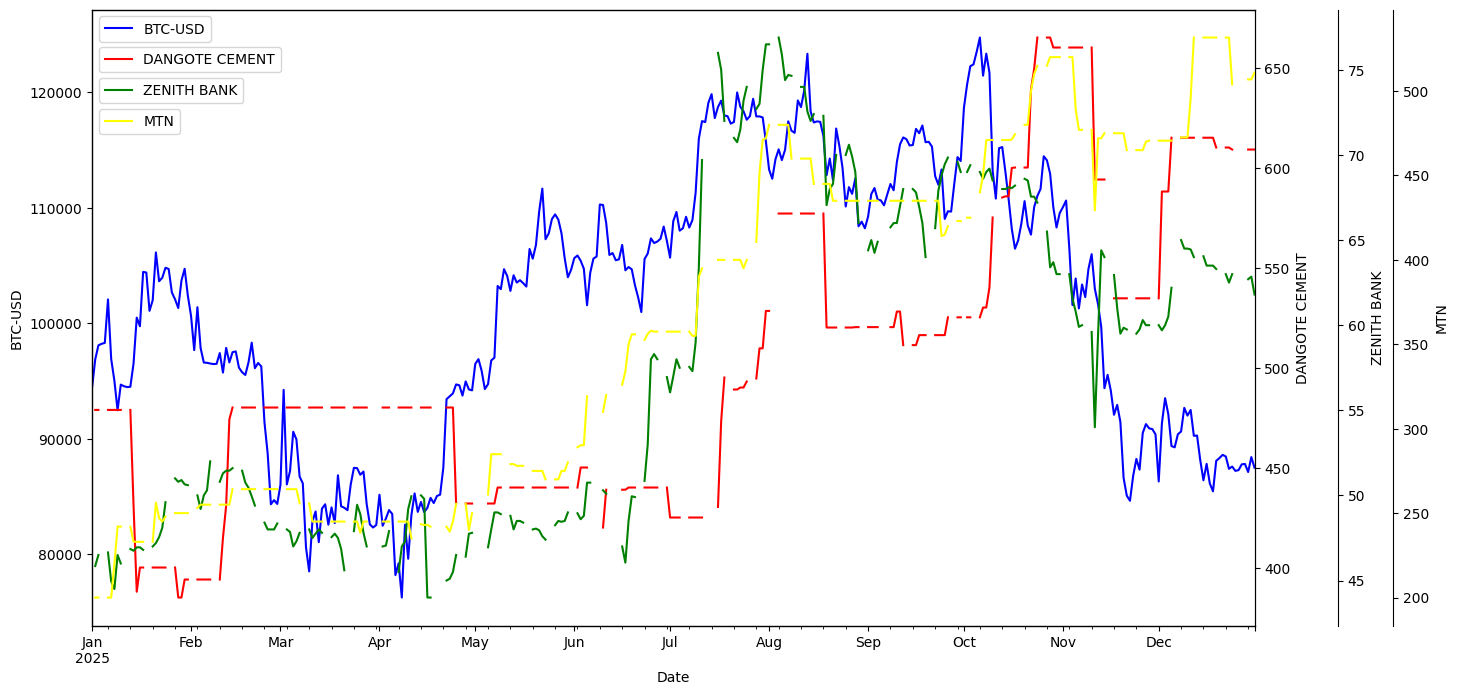

In [14]:
from matplotlib import legend
fig = plt.figure(figsize=(15,8))
ax1 = fig.add_subplot(111)
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax4 = ax1.twinx()

df['2025-01-01': '2025-12-31'].plot(ax=ax1, y='BTC-USD', color='blue', label='BTC-USD', legend=True)
df['2025-01-01': '2025-12-31'].plot(ax=ax2, y="DANGCEM", color="red", label ='DANGOTE CEMENT', legend=True)
df['2025-01-01': '2025-12-31'].plot(ax=ax3, y="ZENITHBANK", color="green", label ='ZENITH BANK', legend=True)
df['2025-01-01': '2025-12-31'].plot(ax=ax4, y="MTNN", color="yellow", label ='MTN', legend=True)

ax1.set_ylabel('BTC-USD')
ax2.set_ylabel('DANGOTE CEMENT')
ax3.set_ylabel('ZENITH BANK')
ax4.set_ylabel('MTN')
ax3.spines['right'].set_position(('outward', 60))
ax4.spines['right'].set_position(('outward', 100))

ax1.legend(['BTC-USD'], loc='upper left')
ax2.legend(['DANGOTE CEMENT'], loc='upper left',  bbox_to_anchor=(0, 0.95))
ax3.legend(['ZENITH BANK'], loc='upper left',  bbox_to_anchor=(0, 0.9))
ax4.legend(['MTN'], loc='upper left',  bbox_to_anchor=(0, 0.85))

plt.show()

In [15]:
df_return = np.log(df / df.shift(1))
df_return.head(10)

,BTC-USD,DANGCEM,ZENITHBANK,MTNN
Date,,,,
2020-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN
2020-01-02 00:00:00+00:00,-0.030273,NaN,NaN,NaN
2020-01-03 00:00:00+00:00,0.050172,0.000000,0.028988,0.000000
2020-01-04 00:00:00+00:00,0.008915,NaN,NaN,NaN
2020-01-05 00:00:00+00:00,0.000089,NaN,NaN,NaN
2020-01-06 00:00:00+00:00,0.047161,NaN,NaN,NaN
2020-01-07 00:00:00+00:00,0.049527,0.027029,0.048790,-0.003711
2020-01-08 00:00:00+00:00,-0.010322,0.089231,0.037388,0.017504
2020-01-09 00:00:00+00:00,-0.025165,0.064920,0.009132,0.057666


In [16]:
avg_annual_return = df_return.mean() * 252
avg_annual_return

,0
BTC-USD,0.288733
DANGCEM,0.236865
ZENITHBANK,0.260677
MTNN,0.287575


In [17]:
avg_daily_return = df_return.mean()
avg_daily_return

,0
BTC-USD,0.001146
DANGCEM,0.000940
ZENITHBANK,0.001034
MTNN,0.001141


In [18]:
df.tail()

,BTC-USD,DANGCEM,ZENITHBANK,MTNN
Date,,,,
2025-12-28 00:00:00+00:00,"87,835.835938",NaN,NaN,NaN
2025-12-29 00:00:00+00:00,"87,138.140625",609.000000,62.700000,506.900000
2025-12-30 00:00:00+00:00,"88,430.132812",609.000000,62.850000,506.900000
2025-12-31 00:00:00+00:00,"87,508.828125",609.000000,61.800000,511.000000
2026-01-01 00:00:00+00:00,"88,731.984375",NaN,NaN,NaN


In [19]:
#High_low Volatility BTC

end = new_end
curr_year = df.loc[end - pd.Timedelta(days=365) : end]

(curr_year.max() - curr_year.min())/df.iloc[-2]

,0
BTC-USD,0.554008
DANGCEM,0.459770
ZENITHBANK,0.532362
MTNN,0.649119


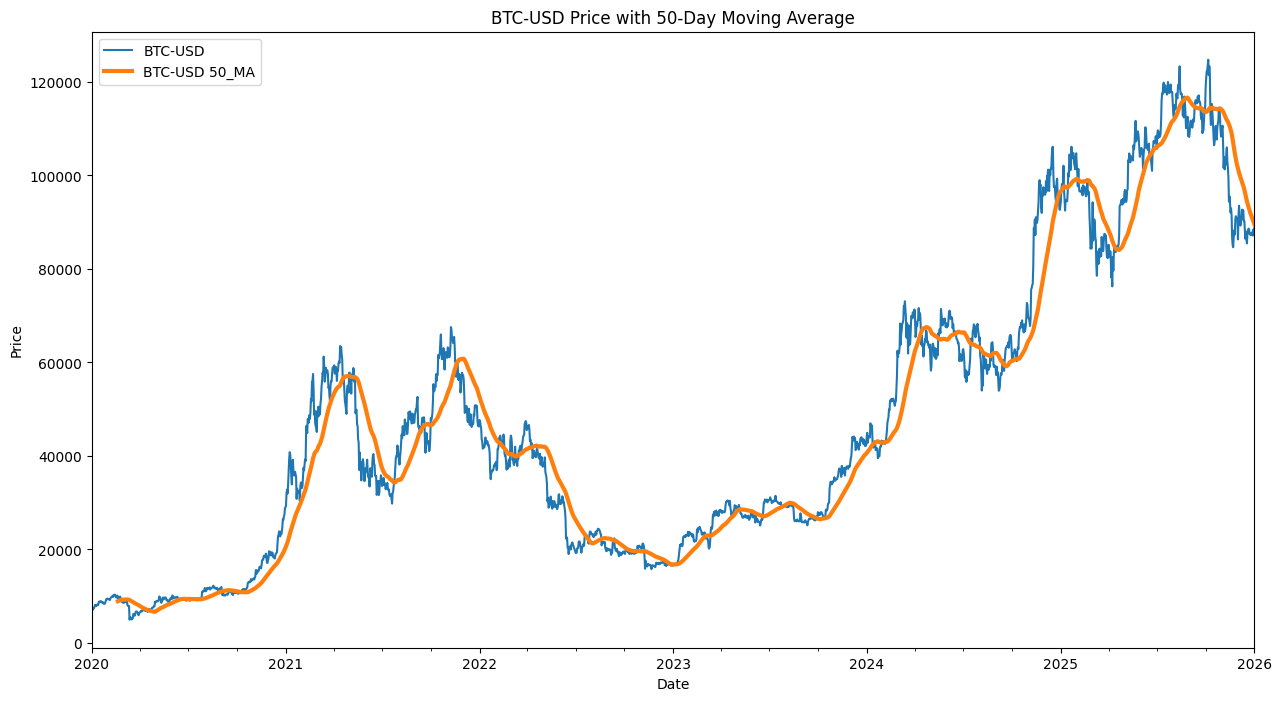

In [20]:
#Moving Average BTC

df['BTC-USD 50_MA'] = df['BTC-USD'].rolling(window=50).mean()

plt.figure(figsize=(15,8))
df["BTC-USD"].plot(label="BTC-USD")
df['BTC-USD 50_MA'].plot(label="BTC-USD 50_MA", linewidth=3)
plt.legend()
plt.title('BTC-USD Price with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

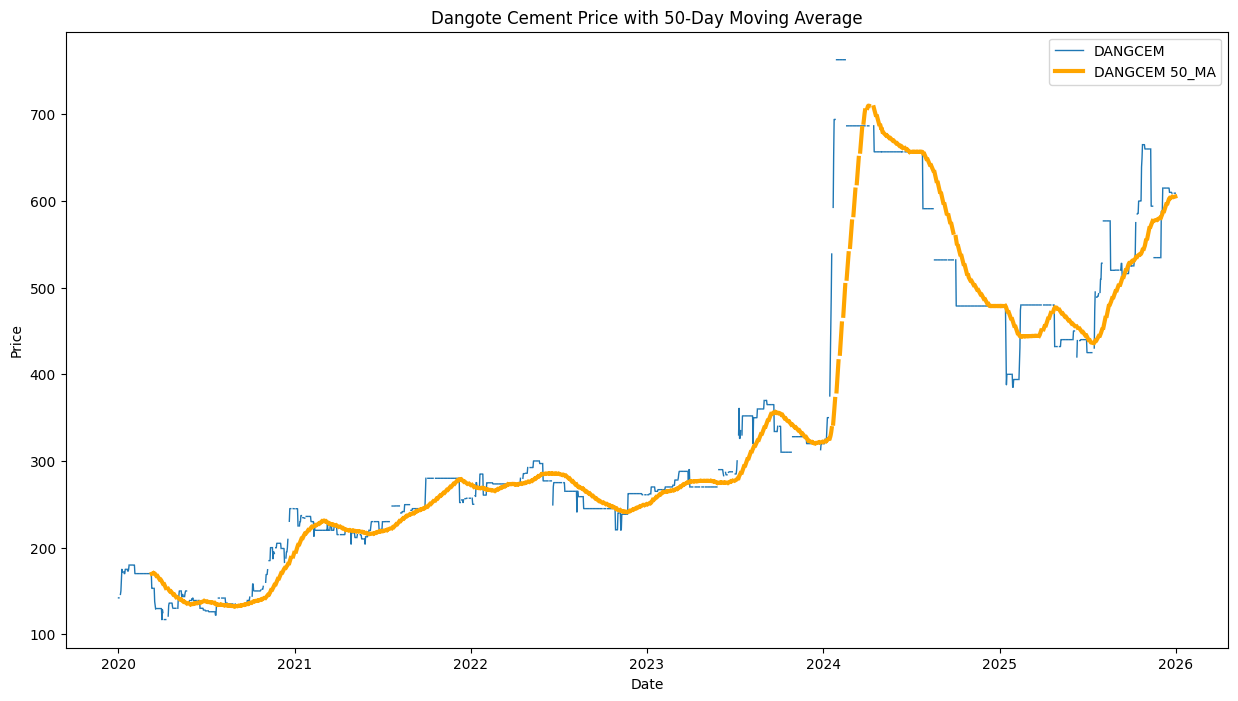

In [21]:
#Moving Average DANGCEM

df['DANGCEM 50_MA'] = df['DANGCEM'].dropna().rolling(window=50).mean().dropna()


plt.figure(figsize=(15, 8))

# Plot both explicitly with matplotlib
plt.plot(df.index, df['DANGCEM'], label='DANGCEM', linewidth=1)
plt.plot(df.index, df['DANGCEM 50_MA'], label='DANGCEM 50_MA',
         linewidth=3, color='orange')

plt.legend()
plt.title('Dangote Cement Price with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

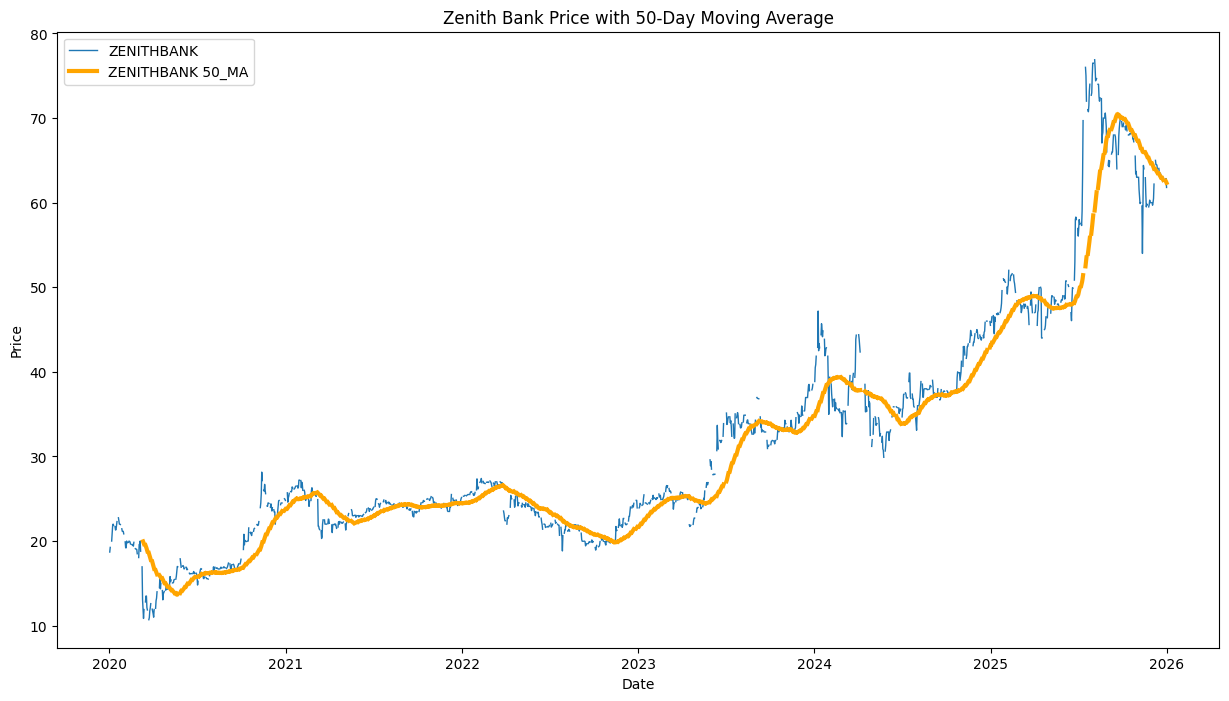

In [22]:
# Moving Avg ZENITH
df['ZENITHBANK 50_MA'] = df['ZENITHBANK'].dropna().rolling(window=50).mean()

plt.figure(figsize=(15, 8))

# Plot both explicitly with matplotlib
plt.plot(df.index, df['ZENITHBANK'], label='ZENITHBANK', linewidth=1)
plt.plot(df.index, df['ZENITHBANK 50_MA'], label='ZENITHBANK 50_MA',
         linewidth=3, color='orange')

plt.legend()
plt.title('Zenith Bank Price with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

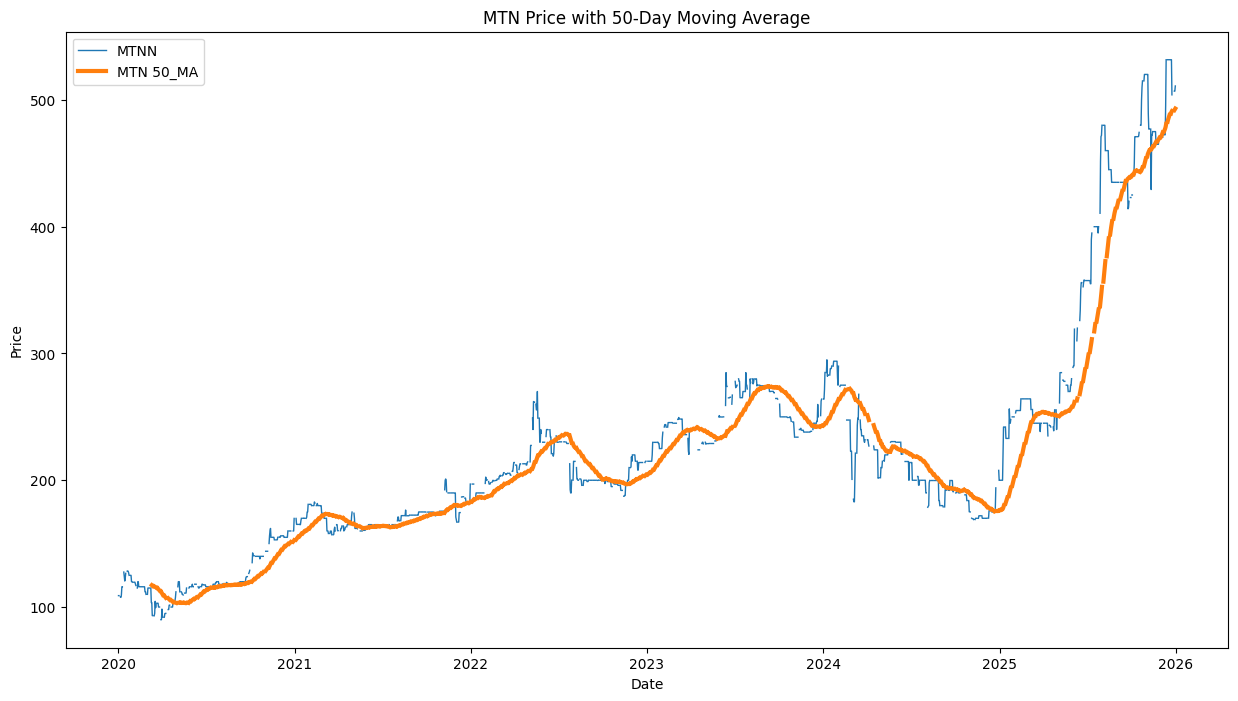

In [23]:
# Moving Avg MTN

df['MTNN 50_MA'] = df['MTNN'].dropna().rolling(window=50).mean()

plt.figure(figsize=(15, 8))
plt.plot(df.index, df['MTNN'], label='MTNN', linewidth=1)
plt.plot(df.index, df['MTNN 50_MA'], label='MTN 50_MA', linewidth=3)
plt.legend()
plt.title('MTN Price with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [24]:
# Rolling distance

(abs(df - df.dropna().rolling(window=50).mean())/df).mean()

,0
BTC-USD,0.128268
DANGCEM,0.063128
ZENITHBANK,0.061156
MTNN,0.061371
BTC-USD 50_MA,0.112639
DANGCEM 50_MA,0.052009
ZENITHBANK 50_MA,0.047254
MTNN 50_MA,0.050401


In [25]:
# Standard Deviations

df_return.std()

,0
BTC-USD,0.032367
DANGCEM,0.022329
ZENITHBANK,0.024829
MTNN,0.021556


In [26]:
def InvestmentComparison(startTime, endTime, df):
  startTime = pd.Timestamp(startTime).tz_localize('UTC')
  endTime = pd.Timestamp(endTime).tz_localize('UTC')

  returns = np.log(df)-np.log(df.shift(1))
  returns = returns.iloc[1:, 0:]

  curr_year= df.loc[endTime - pd.Timedelta(days=365) : endTime]


  highlow_series = (curr_year.max() - curr_year.min()) / df.iloc[-2]


  # Calculate MA as a Series, considering only original asset columns
  ma_series = (abs(df - df.dropna().rolling(window=50).mean())/df).mean()

  # Calculate std as a Series
  std_series = returns.std()

  # Calculate daily return as a Series
  daily_return_series = returns.mean()

  # Combine all Series into a single DataFrame
  investment = pd.DataFrame({
      'highlow': highlow_series,
      'MA': ma_series,
      'std': std_series,
      'daily return': daily_return_series
  })

  # Format the columns
  investment['highlow'] = investment['highlow'].round(4).astype(str)

  # Format other columns as percentages
  for col_name in ["std", "daily return", 'MA']:
    investment[col_name] = (investment[col_name]*100).round(3).astype(str) + '%'

  return investment

In [27]:
InvestmentComparison('2020-01-01', '2026-01-01', df)

,highlow,MA,std,daily return
BTC-USD,0.554,12.827%,3.237%,0.115%
DANGCEM,0.4598,6.313%,2.233%,0.094%
ZENITHBANK,0.5324,6.116%,2.483%,0.103%
MTNN,0.6491,6.137%,2.156%,0.114%
BTC-USD 50_MA,0.3628,11.264%,0.504%,0.108%
DANGCEM 50_MA,0.2789,5.201%,0.398%,0.091%
ZENITHBANK 50_MA,0.4359,4.725%,0.327%,0.079%
MTNN 50_MA,0.6422,5.04%,0.301%,0.102%


In [29]:
InvestmentComparison('2024-01-01', '2025-01-01', df_test)

,highlow,MA,std,daily return
BTC-USD,0.7614,13.211%,3.237%,0.115%
DANGCEM,0.7276,6.651%,2.233%,0.094%
ZENITHBANK,0.2798,6.819%,2.483%,0.103%
MTNN,0.2466,6.312%,2.156%,0.114%
